# Tile Registration Workbook
### Monje Lab — horizontal pair registration comparison

Four methods side-by-side, all using sinusoidal blending:

| Step | Description |
|------|-------------|
| 0 | **Naive** — fixed 20 % overlap, no shift correction |
| 1 | **PCC (full frames)** — skimage PCC on the two raw images |
| 2 | **PCC (overlap strips)** — PCC on the predefined overlap region only |
| 3 | **PCC (masked overlap)** — Otsu-thresholded mask → PCC on foreground pixels only |

Each step prints the detected shift and renders a red/green/yellow overlay.


In [64]:
# ── Imports ──────────────────────────────────────────────────────────────
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tifffile

from pathlib import Path
from skimage.registration import phase_cross_correlation
from skimage.filters import threshold_otsu

matplotlib.rcParams["figure.dpi"] = 120


In [65]:
# ── Helper functions ─────────────────────────────────────────────────────

def load_tile(path: str | Path) -> np.ndarray:
    """Load a TIFF → 2-D float32 (collapses extra leading dims)."""
    img = tifffile.imread(str(path)).astype(np.float32)
    while img.ndim > 2:
        img = img[0]
    return img


def norm_disp(img: np.ndarray) -> np.ndarray:
    """Normalise to [0, 1] for display."""
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo + 1e-9)


def run_pcc(ref: np.ndarray, mov: np.ndarray, upsample: int = 20):
    """
    Phase cross-correlation (normalization=None).
    Crops to common shape if needed.
    Returns (dy, dx, error).
    """
    if ref.shape != mov.shape:
        r = min(ref.shape[0], mov.shape[0])
        c = min(ref.shape[1], mov.shape[1])
        ref, mov = ref[:r, :c], mov[:r, :c]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        shift, error, _ = phase_cross_correlation(
            ref, mov,
            upsample_factor=upsample,
            normalization=None,
        )
    return float(shift[0]), float(shift[1]), float(error)


def sinusoidal_blend(strip_a: np.ndarray, strip_b: np.ndarray) -> np.ndarray:
    """
    Raised-cosine blend across columns (horizontal seam).
    Weight goes 1→0 (full a → full b).
    Zero pixels yield full weight to the other tile.
    """
    n = strip_a.shape[1]
    t = np.linspace(0.0, 1.0, n, dtype=np.float32)
    w = (0.5 * (1.0 + np.cos(np.pi * t)))          # 1 → 0
    ramp = np.broadcast_to(w, strip_a.shape).copy()
    ramp[strip_a == 0] = 0.0
    ramp[strip_b == 0] = 1.0
    return ramp * strip_a + (1.0 - ramp) * strip_b


def stitch_horizontal(img_a: np.ndarray, img_b: np.ndarray,
                      overlap_px: int) -> np.ndarray:
    """
    Stitch img_b to the right of img_a with sinusoidal blending.
    Both images are used at full resolution; overlap is blended.
    Heights are matched by bottom-padding the shorter image.
    """
    # Match heights
    ha, hb = img_a.shape[0], img_b.shape[0]
    target_h = max(ha, hb)
    if ha < target_h:
        img_a = np.pad(img_a, ((0, target_h - ha), (0, 0)))
    if hb < target_h:
        img_b = np.pad(img_b, ((0, target_h - hb), (0, 0)))

    overlap_px = max(1, min(overlap_px, img_a.shape[1], img_b.shape[1]))
    body_a  = img_a[:,  :-overlap_px]
    strip_a = img_a[:,  -overlap_px:]
    strip_b = img_b[:,  :overlap_px]
    body_b  = img_b[:,  overlap_px:]
    blended = sinusoidal_blend(strip_a, strip_b)
    return np.concatenate([body_a, blended, body_b], axis=1)


def place_with_shift(img_a: np.ndarray, img_b: np.ndarray,
                     overlap_px: int, dy: float, dx: float) -> np.ndarray:
    """
    Composite img_b onto a canvas so that its left edge lands at
    x = (width_a − overlap_px + dx) and its top edge at y = dy.
    Uses sinusoidal blending in the overlap zone.
    Handles integer dy/dx offsets by shifting where img_b is pasted.
    """
    idy = int(round(dy))
    idx = int(round(dx))

    # Adjusted overlap after horizontal shift
    adj_overlap = overlap_px - idx
    adj_overlap = max(1, adj_overlap)

    # Build canvas large enough for both tiles
    h_a, w_a = img_a.shape
    h_b, w_b = img_b.shape
    canvas_h = max(h_a, h_b + abs(idy)) + abs(idy)
    canvas_w = w_a + w_b  # generous upper bound

    canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)

    # Place img_a at (0, 0)
    canvas[:h_a, :w_a] += img_a

    # Place img_b at (idy, w_a - adj_overlap)
    b_y0 = max(0, idy)
    b_x0 = w_a - adj_overlap
    b_y0_src = max(0, -idy)

    h_b_clip = min(h_b - b_y0_src, canvas_h - b_y0)
    w_b_clip = min(w_b, canvas_w - b_x0)

    if h_b_clip <= 0 or w_b_clip <= 0:
        # Degenerate — fall back to raw concatenation
        return stitch_horizontal(img_a, img_b, overlap_px)

    img_b_crop = img_b[b_y0_src:b_y0_src + h_b_clip, :w_b_clip]

    # Build stitch for the overlap zone
    ov_region = min(adj_overlap, w_b_clip, w_a - max(0, b_x0))
    ov_region = max(1, ov_region)

    # Simple approach: use stitch_horizontal on the shifted crops
    a_crop = canvas[:h_a, :w_a].copy()  # original img_a
    stitched = stitch_horizontal(a_crop, img_b_crop, ov_region)

    # Trim trailing zeros
    last_nonzero_col = np.flatnonzero(stitched.any(axis=0))
    if last_nonzero_col.size:
        stitched = stitched[:, :last_nonzero_col[-1] + 1]
    last_nonzero_row = np.flatnonzero(stitched.any(axis=1))
    if last_nonzero_row.size:
        stitched = stitched[:last_nonzero_row[-1] + 1, :]

    return stitched


def overlay_rgy(img_a: np.ndarray, img_b: np.ndarray,
                overlap_px: int, dy: float = 0.0, dx: float = 0.0,
                title: str = "") -> None:
    """
    Red / Green / Yellow overlay for visual alignment assessment.
    Red   = img_a only
    Green = img_b only (shifted by dy, dx relative to its nominal position)
    Yellow = both (overlap region)

    img_a is placed at origin.
    img_b left edge at x = w_a - overlap_px + dx, top at y = dy.
    """
    idy = int(round(dy))
    idx = int(round(dx))

    h_a, w_a = img_a.shape
    h_b, w_b = img_b.shape

    # Canvas size
    b_x0 = w_a - overlap_px + idx
    b_y0 = idy
    canvas_h = max(h_a, b_y0 + h_b, 1) + abs(idy)
    canvas_w = max(w_a, b_x0 + w_b, 1)
    canvas_h = max(canvas_h, 1)
    canvas_w = max(canvas_w, 1)

    ch_a = np.zeros((canvas_h, canvas_w), dtype=np.float32)
    ch_b = np.zeros((canvas_h, canvas_w), dtype=np.float32)

    # Place img_a
    ch_a[:h_a, :w_a] = norm_disp(img_a)

    # Place img_b
    by0 = max(0, b_y0);  by0_src = max(0, -b_y0)
    bx0 = max(0, b_x0);  bx0_src = max(0, -b_x0)
    h_clip = min(h_b - by0_src, canvas_h - by0)
    w_clip = min(w_b - bx0_src, canvas_w - bx0)
    if h_clip > 0 and w_clip > 0:
        ch_b[by0:by0 + h_clip, bx0:bx0 + w_clip] = \
            norm_disp(img_b[by0_src:by0_src + h_clip, bx0_src:bx0_src + w_clip])

    # Compose RGB: R=a, G=b, B=0
    rgb = np.stack([ch_a, ch_b, np.zeros_like(ch_a)], axis=-1)

    fig, ax = plt.subplots(figsize=(min(14, canvas_w // 100 + 4), 5))
    ax.imshow(rgb, aspect="auto")
    ax.axvline(w_a - 1, color="cyan", lw=0.8, linestyle="--", alpha=0.6,
               label=f"A right edge (x={w_a-1})")
    ax.axvline(b_x0, color="magenta", lw=0.8, linestyle="--", alpha=0.6,
               label=f"B left edge (x={b_x0})")

    patch_r = mpatches.Patch(color=(1, 0, 0), label="Tile A only")
    patch_g = mpatches.Patch(color=(0, 1, 0), label="Tile B only")
    patch_y = mpatches.Patch(color=(1, 1, 0), label="Overlap (both)")
    ax.legend(handles=[patch_r, patch_g, patch_y], loc="upper right",
              fontsize=7, framealpha=0.6)
    ax.set_title(f"{title}  |  dy={dy:+.1f}  dx={dx:+.1f}  overlap={overlap_px}px",
                 fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"  Shift: dy={dy:+.2f}, dx={dx:+.2f}")


In [66]:
# ── User Inputs ─────────────────────────────────────────────────────────
# Paths to the two horizontally adjacent tiles (A = left, B = right)

# Test Case 1
## TILE_A_PATH = "/Users/spaltahill/test_images/260128_UltraII_5300148-2R_AF_HNACy3_cfos_2x_thickness3d5_width60_20ol_10umstep[00 x 00]_C00_z0192.ome.tif"
## TILE_B_PATH = "/Users/spaltahill/test_images/260128_UltraII_5300148-2R_AF_HNACy3_cfos_2x_thickness3d5_width60_20ol_10umstep[00 x 01]_C00_z0192.ome.tif"

## Test Case 2
## TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 00]_C00_z0198.ome.tif"
## TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 01]_C00_z0198.ome.tif"

## Test Case 3
## TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[02 x 01]_C00_z0198.ome.tif"
## TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[02 x 02]_C00_z0198.ome.tif"

## Test Case 4
## TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 01]_C00_z0100.ome.tif"
## TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[01 x 02]_C00_z0100.ome.tif"

## Test Case 5
## TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[03 x 01]_C00_z0100.ome.tif"
## TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[03 x 02]_C00_z0100.ome.tif"

## Test Case 6
TILE_A_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[00 x 00]_C00_z0198.ome.tif"
TILE_B_PATH = "/Users/spaltahill/test_images2/260206_UltraII_5300148-3R_AFp80_HNACy3p40_cfos647p80_2x_thickness3d5_width60_20ol_10umstep[00 x 01]_C00_z0198.ome.tif"

# Nominal overlap as a fraction of tile width
# Step 0 (naive): fixed overlap assumed
OVERLAP_FRAC_NAIVE = 0.20
# Steps 1–3 (PCC methods): wider overlap strip for registration
OVERLAP_FRAC_PCC = 0.50

# Otsu multiplier for Step 3 masking.
# Threshold used = OTSU_MULTIPLIER * otsu(overlap_strip)
# <1.0 → more permissive (include dimmer signal)
# >1.0 → stricter (foreground only)
OTSU_MULTIPLIER = 0.5

# PCC upsample factor (higher = sub-pixel precision, slower)
UPSAMPLE = 20


Tile A shape : (2560, 2160)  dtype=float32
Tile B shape : (2560, 2160)  dtype=float32
Naive overlap : 432 px  (20% of 2160)
PCC overlap   : 1080 px  (50% of 2160)


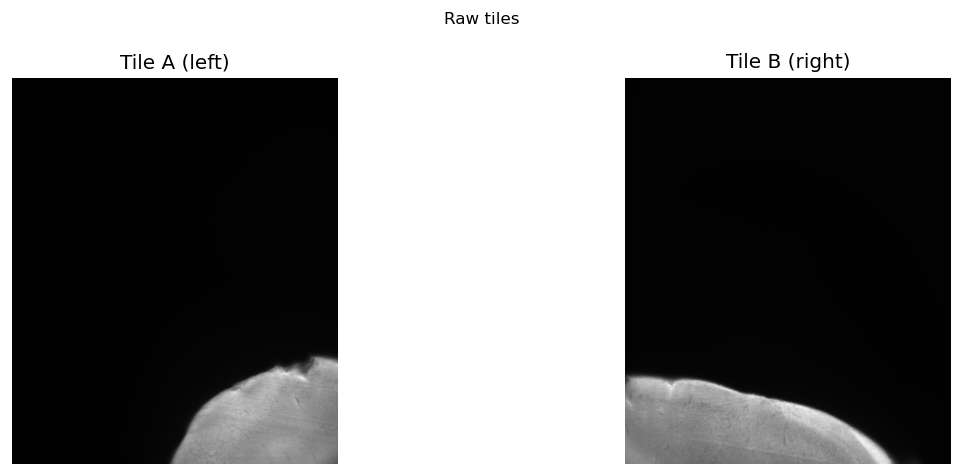

In [67]:
# ── Load tiles ───────────────────────────────────────────────────────────
img_a = load_tile(TILE_A_PATH)
img_b = load_tile(TILE_B_PATH)

overlap_px_naive = int(round(OVERLAP_FRAC_NAIVE * img_a.shape[1]))
overlap_px_pcc   = int(round(OVERLAP_FRAC_PCC   * img_a.shape[1]))

print(f"Tile A shape : {img_a.shape}  dtype={img_a.dtype}")
print(f"Tile B shape : {img_b.shape}  dtype={img_b.dtype}")
print(f"Naive overlap : {overlap_px_naive} px  ({OVERLAP_FRAC_NAIVE*100:.0f}% of {img_a.shape[1]})")
print(f"PCC overlap   : {overlap_px_pcc} px  ({OVERLAP_FRAC_PCC*100:.0f}% of {img_a.shape[1]})")

# Quick sanity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(norm_disp(img_a), cmap="gray")
axes[0].set_title("Tile A (left)")
axes[0].axis("off")
axes[1].imshow(norm_disp(img_b), cmap="gray")
axes[1].set_title("Tile B (right)")
axes[1].axis("off")
plt.suptitle("Raw tiles", fontsize=10)
plt.tight_layout()
plt.show()


---
## Step 0 — Naive stitch (no registration)
Assume exactly `OVERLAP_FRAC_NAIVE` overlap and concatenate with sinusoidal blending.
No shift correction applied.


Stitched canvas: (2560, 3888)


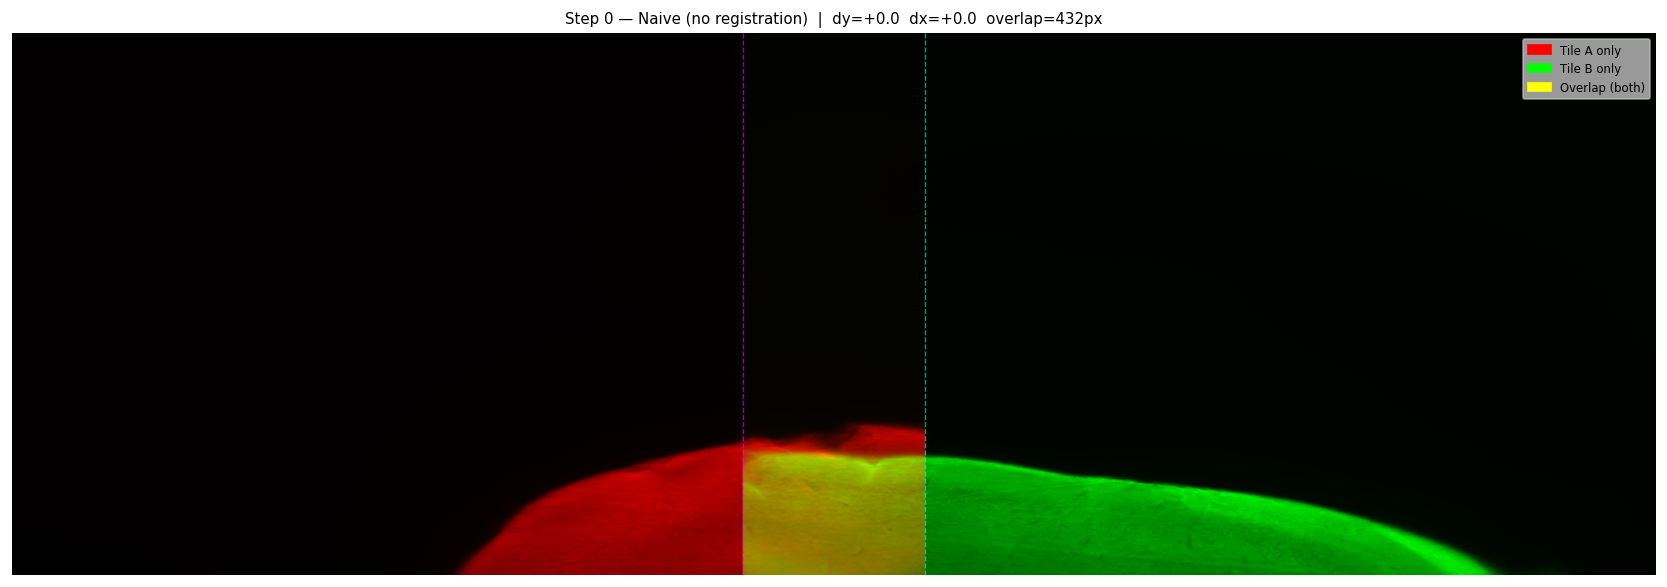

  Shift: dy=+0.00, dx=+0.00


In [68]:
# ── Step 0: Naive stitch ─────────────────────────────────────────────────
result_naive = stitch_horizontal(img_a, img_b, overlap_px_naive)
print(f"Stitched canvas: {result_naive.shape}")

overlay_rgy(img_a, img_b, overlap_px_naive,
            dy=0.0, dx=0.0,
            title="Step 0 — Naive (no registration)")


---
## Step 1 — PCC on full raw images
`phase_cross_correlation` called directly on the two full-size tiles.
The returned shift tells us how much to translate B to align it with A.

> **Note:** Full-frame PCC treats the entire tile content as the signal.
> It works well when tiles share a lot of overlapping structure, but can be
> confused by the large non-overlapping regions.


Full-frame PCC  →  dy=+0.00  dx=-1049.10  error=nan


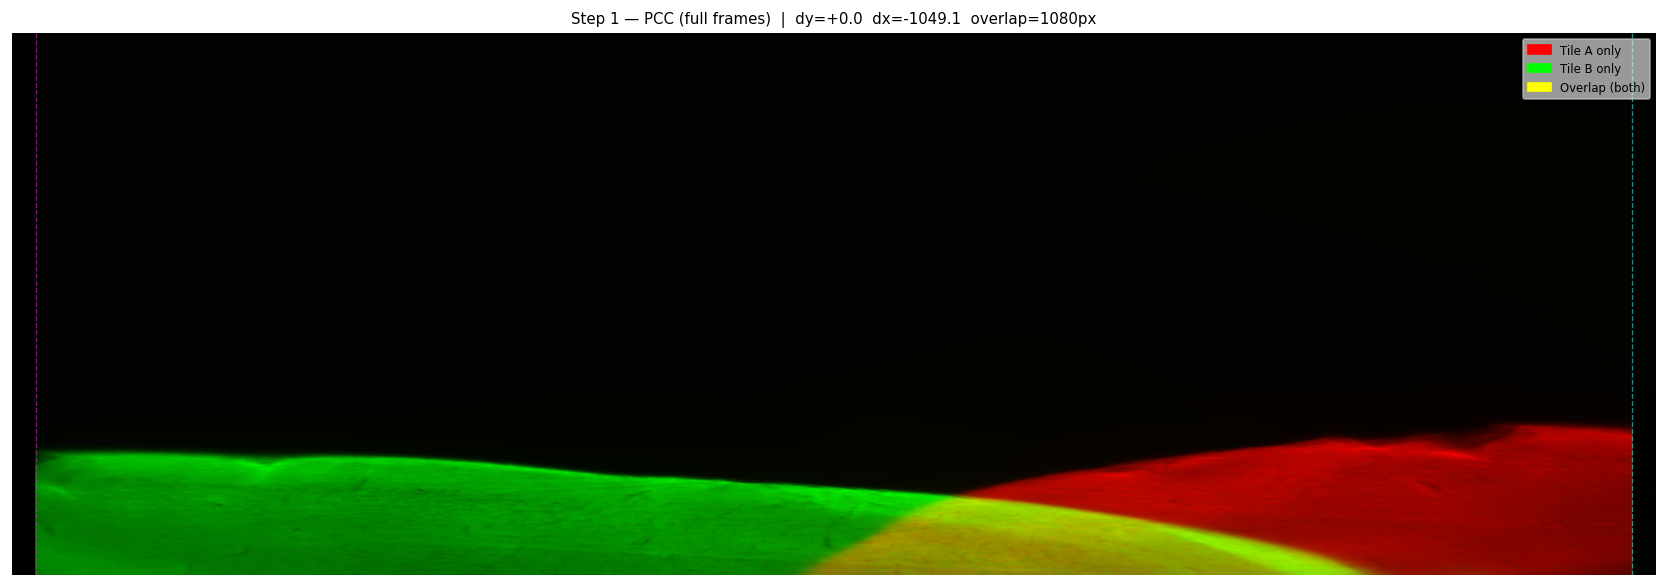

  Shift: dy=+0.00, dx=-1049.10


In [69]:
# ── Step 1: PCC on full frames ───────────────────────────────────────────
dy1, dx1, err1 = run_pcc(img_a, img_b, upsample=UPSAMPLE)
print(f"Full-frame PCC  →  dy={dy1:+.2f}  dx={dx1:+.2f}  error={err1:.4f}")

overlay_rgy(img_a, img_b, overlap_px_pcc,
            dy=dy1, dx=dx1,
            title="Step 1 — PCC (full frames)")


---
## Step 2 — PCC on predefined overlap strips
Extract the rightmost `overlap_px` columns of A and leftmost `overlap_px`
columns of B, then run PCC on just those strips.
The resulting shift is applied when compositing onto the canvas.

> **Why this is better:** PCC sees only the region that is actually shared,
> reducing noise from non-overlapping content.


Overlap-strip PCC  →  dy=-0.20  dx=+400.95  error=nan


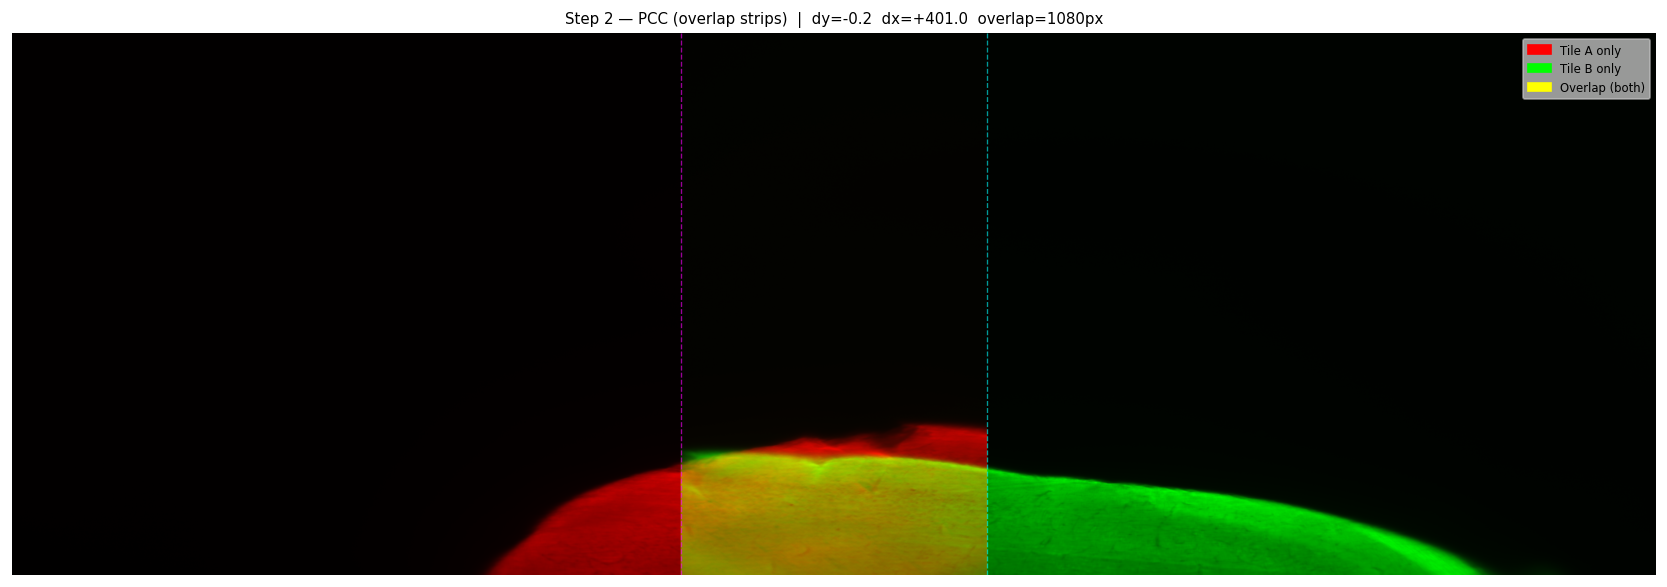

  Shift: dy=-0.20, dx=+400.95


In [70]:
# ── Step 2: PCC on overlap strips ────────────────────────────────────────
strip_a2 = img_a[:, -overlap_px_pcc:]   # right edge of A
strip_b2 = img_b[:,  :overlap_px_pcc]   # left  edge of B

dy2, dx2, err2 = run_pcc(strip_a2, strip_b2, upsample=UPSAMPLE)
print(f"Overlap-strip PCC  →  dy={dy2:+.2f}  dx={dx2:+.2f}  error={err2:.4f}")

overlay_rgy(img_a, img_b, overlap_px_pcc,
            dy=dy2, dx=dx2,
            title="Step 2 — PCC (overlap strips)")


---
## Step 3 — PCC on Otsu-masked overlap strips
1. Compute an Otsu threshold on each overlap strip independently.
2. Apply `OTSU_MULTIPLIER` to get the effective threshold.
3. Zero out background pixels (below threshold) in each strip.
4. Run PCC on the masked strips; apply the shift to the full raw images.

> **Why this helps:** Background pixels are often flat/noisy and can dominate
> the cross-correlation. Masking focuses PCC on actual signal structure.
> Lowering `OTSU_MULTIPLIER` (e.g. 0.5) includes dimmer signal;
> raising it towards 1.0 restricts to the brightest foreground.


Otsu(A strip) = 7775.51  →  threshold used = 3887.75
Otsu(B strip) = 6301.40  →  threshold used = 3150.70
Foreground coverage: A=21.2%  B=20.7%


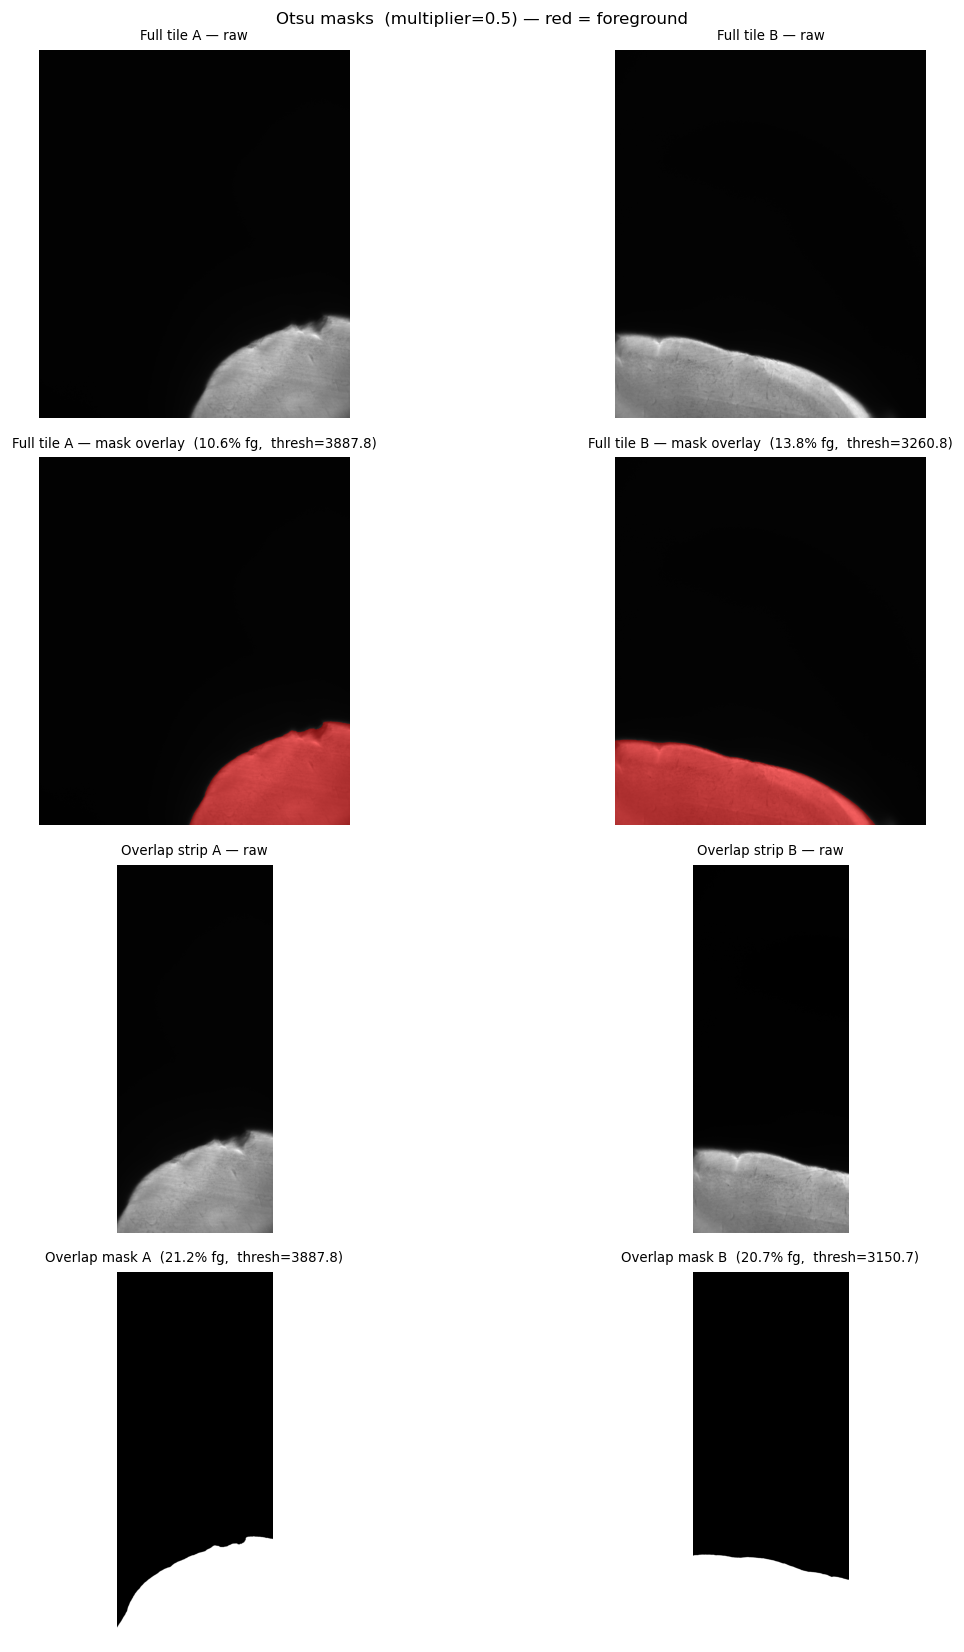

Masked PCC  →  dy=-118.00  dx=+890.00  error=nan


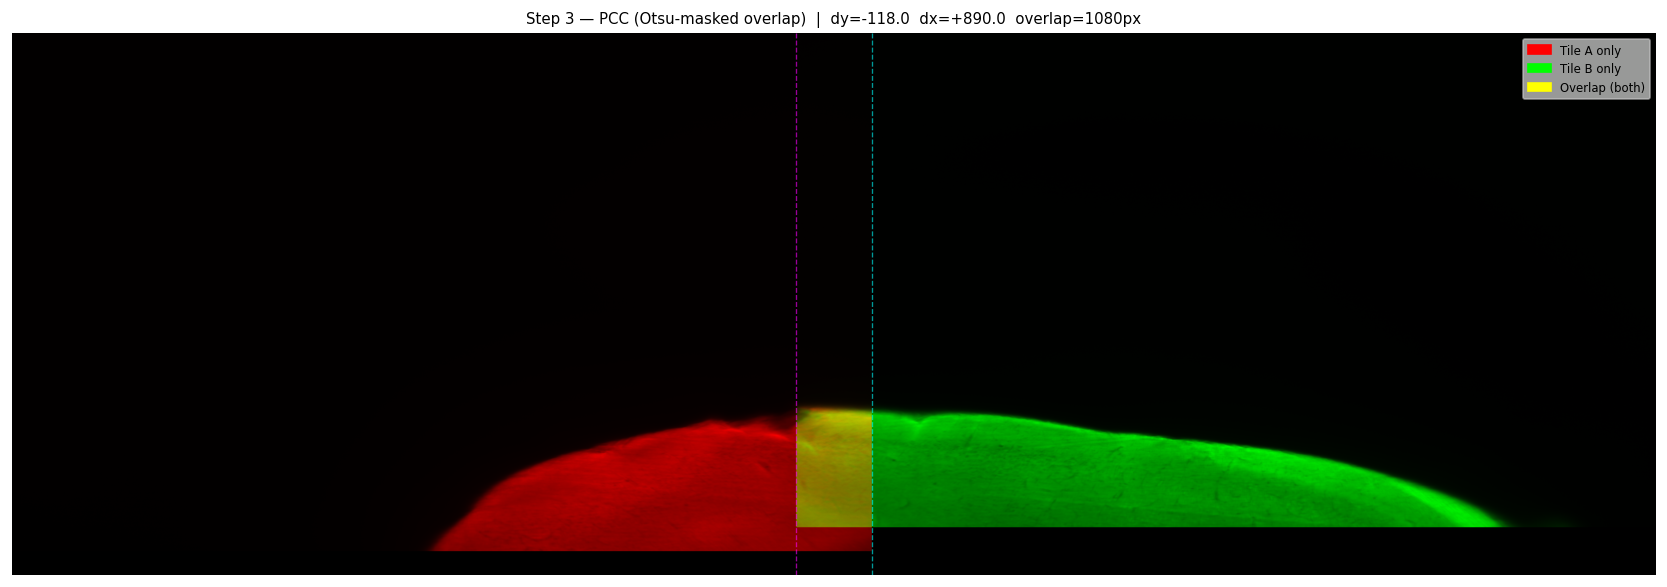

  Shift: dy=-118.00, dx=+890.00


In [71]:
# ── Step 3: Otsu-masked PCC ──────────────────────────────────────────────

# Extract the overlap strips (same as Step 2)
strip_a3 = img_a[:, -overlap_px_pcc:].copy()
strip_b3 = img_b[:,  :overlap_px_pcc].copy()

# Compute per-strip Otsu thresholds
otsu_a = threshold_otsu(strip_a3)
otsu_b = threshold_otsu(strip_b3)
thresh_a = OTSU_MULTIPLIER * otsu_a
thresh_b = OTSU_MULTIPLIER * otsu_b

print(f"Otsu(A strip) = {otsu_a:.2f}  →  threshold used = {thresh_a:.2f}")
print(f"Otsu(B strip) = {otsu_b:.2f}  →  threshold used = {thresh_b:.2f}")

# Build masks
mask_a3 = strip_a3 > thresh_a
mask_b3 = strip_b3 > thresh_b
fg_pct_a = 100.0 * mask_a3.sum() / mask_a3.size
fg_pct_b = 100.0 * mask_b3.sum() / mask_b3.size
print(f"Foreground coverage: A={fg_pct_a:.1f}%  B={fg_pct_b:.1f}%")

# ── Mask visualisation ───────────────────────────────────────────────────
# Build full-image masks by thresholding on the whole tile
# (same multiplied-Otsu logic, applied to img_a / img_b directly)
full_thresh_a = OTSU_MULTIPLIER * threshold_otsu(img_a)
full_thresh_b = OTSU_MULTIPLIER * threshold_otsu(img_b)
full_mask_a = img_a > full_thresh_a
full_mask_b = img_b > full_thresh_b
full_fg_a = 100.0 * full_mask_a.sum() / full_mask_a.size
full_fg_b = 100.0 * full_mask_b.sum() / full_mask_b.size

# Row 1 — full raw images with mask overlaid as a red tint
def make_mask_overlay(img, mask):
    """Return an RGB image: grayscale base + red channel highlight for fg."""
    g = norm_disp(img)
    rgb = np.stack([g, g, g], axis=-1)
    rgb[mask, 0] = np.clip(g[mask] * 0.6 + 0.4, 0, 1)  # boost red
    rgb[mask, 1] = g[mask] * 0.4                         # dim green
    rgb[mask, 2] = g[mask] * 0.4                         # dim blue
    return rgb

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

# Row 0: full raw images (plain grayscale, for reference)
axes[0, 0].imshow(norm_disp(img_a), cmap="gray")
axes[0, 0].set_title("Full tile A — raw", fontsize=8)
axes[0, 0].axis("off")
axes[0, 1].imshow(norm_disp(img_b), cmap="gray")
axes[0, 1].set_title("Full tile B — raw", fontsize=8)
axes[0, 1].axis("off")

# Row 1: full raw images + mask overlay
axes[1, 0].imshow(make_mask_overlay(img_a, full_mask_a))
axes[1, 0].set_title(f"Full tile A — mask overlay  ({full_fg_a:.1f}% fg,  thresh={full_thresh_a:.1f})", fontsize=8)
axes[1, 0].axis("off")
axes[1, 1].imshow(make_mask_overlay(img_b, full_mask_b))
axes[1, 1].set_title(f"Full tile B — mask overlay  ({full_fg_b:.1f}% fg,  thresh={full_thresh_b:.1f})", fontsize=8)
axes[1, 1].axis("off")

# Row 2: overlap strips (raw)
axes[2, 0].imshow(norm_disp(strip_a3), cmap="gray")
axes[2, 0].set_title("Overlap strip A — raw", fontsize=8)
axes[2, 0].axis("off")
axes[2, 1].imshow(norm_disp(strip_b3), cmap="gray")
axes[2, 1].set_title("Overlap strip B — raw", fontsize=8)
axes[2, 1].axis("off")

# Row 3: overlap strip masks (binary)
axes[3, 0].imshow(mask_a3.astype(np.uint8), cmap="gray", vmin=0, vmax=1)
axes[3, 0].set_title(f"Overlap mask A  ({fg_pct_a:.1f}% fg,  thresh={thresh_a:.1f})", fontsize=8)
axes[3, 0].axis("off")
axes[3, 1].imshow(mask_b3.astype(np.uint8), cmap="gray", vmin=0, vmax=1)
axes[3, 1].set_title(f"Overlap mask B  ({fg_pct_b:.1f}% fg,  thresh={thresh_b:.1f})", fontsize=8)
axes[3, 1].axis("off")

plt.suptitle(f"Otsu masks  (multiplier={OTSU_MULTIPLIER}) — red = foreground", fontsize=10)
plt.tight_layout()
plt.show()

# Apply masks (zero background)
sa3_masked = strip_a3.copy(); sa3_masked[~mask_a3] = 0.0
sb3_masked = strip_b3.copy(); sb3_masked[~mask_b3] = 0.0

# PCC on masked strips — pass masks directly so skimage uses masked NCC algorithm,
# which handles sparse/edge-hugging signal correctly without manual cropping
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shift, err3, _ = phase_cross_correlation(
        strip_a3, strip_b3,
        reference_mask=mask_a3,
        moving_mask=mask_b3,
        overlap_ratio=0.1,   # allow low overlap — our signal may only cover a small fraction
    )
dy3, dx3 = float(shift[0]), float(shift[1])
# note: masked PCC always returns NaN for error — that's expected per the docs
print(f"Masked PCC  →  dy={dy3:+.2f}  dx={dx3:+.2f}  error={err3}")

overlay_rgy(img_a, img_b, overlap_px_pcc,
            dy=dy3, dx=dx3,
            title="Step 3 — PCC (Otsu-masked overlap)")


---
## Summary


In [72]:
# ── Summary table ────────────────────────────────────────────────────────
rows = [
    ("Step 0", "Naive",                    0.0,  0.0,  None),
    ("Step 1", "PCC — full frames",        dy1,  dx1,  err1),
    ("Step 2", "PCC — overlap strips",     dy2,  dx2,  err2),
    ("Step 3", "PCC — masked overlap",     dy3,  dx3,  err3),
]

print(f"{'Step':<8} {'Method':<30} {'dy':>8} {'dx':>8} {'PCC err':>10}")
print("-" * 68)
for step, method, dy, dx, err in rows:
    err_str = f"{err:.4f}" if err is not None else "  —"
    print(f"{step:<8} {method:<30} {dy:>+8.2f} {dx:>+8.2f} {err_str:>10}")


Step     Method                               dy       dx    PCC err
--------------------------------------------------------------------
Step 0   Naive                             +0.00    +0.00          —
Step 1   PCC — full frames                 +0.00 -1049.10        nan
Step 2   PCC — overlap strips              -0.20  +400.95        nan
Step 3   PCC — masked overlap            -118.00  +890.00        nan
